In [2]:
import pandas as pd
import matplotlib.pyplot as plt
from scipy.optimize import curve_fit
from scipy.stats import norm
import numpy as np

In [3]:
# INPUT_FILE = "regional_temp_data.csv"
# OUTPUT_FILE = "temp_models.csv"
# USE_LN = False

INPUT_FILE = "regional_ed_data.csv"
OUTPUT_FILE = "ed_models.csv"
USE_LN = True

In [4]:
OMEGA = 1/365.25
PHI = 2*np.pi*OMEGA

def f(t, beta_0, beta_s, beta_c):
    if USE_LN:
        return np.exp(beta_0 + beta_s*np.sin(PHI*t) + beta_c*np.cos(PHI*t))
    else:
        return beta_0 + beta_s*np.sin(PHI*t) + beta_c*np.cos(PHI*t)

In [5]:
df = pd.read_csv(INPUT_FILE, index_col=0)
y_min = df.values.min()
y_max = df.values.max()
y_range = y_max - y_min
df.head()

,Region 1,Region 2,Region 3,Region 4,Region 5,Region 6,Region 7,Region 8,Region 9,Region 10
temporal,,,,,,,,,,
2017-12-31,0,5,0,5,5,0,0,0,0,0
2018-01-01,7,12,7,0,9,0,34,0,0,48
2018-01-02,0,13,10,5,8,0,133,0,0,0
2018-01-03,0,6,4,3,0,5,36,0,11,0
2018-01-04,11,5,0,8,6,0,0,0,16,0


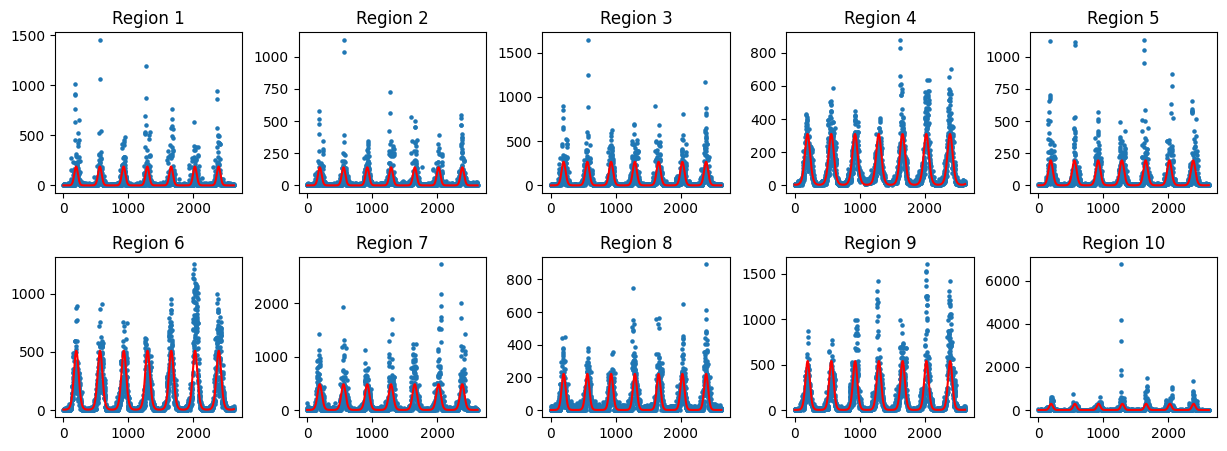

,region,beta_0,beta_s,beta_c,sigma_00,sigma_0s,sigma_0c,sigma_ss,sigma_sc,sigma_cc,psi,var_psi,peak_T,sigma_peak_T,peak_T_CI_lower,peak_T_CI_upper,gamma,var_gamma,theta
0,Region 1,0.748092,-0.996778,-4.380750,0.081335,0.019003,0.083517,0.009922,0.018418,0.086678,0.223727,0.000284,195.630541,0.979514,193.710729,197.550353,4.492721,0.074931,89.364251
1,Region 2,0.456689,-0.950991,-4.385436,0.066841,0.014918,0.068793,0.007859,0.014492,0.071542,0.213546,0.000234,195.038698,0.889649,193.295019,196.782377,4.487364,0.062679,88.886801
2,Region 3,2.050015,-0.775820,-3.449845,0.023703,0.005544,0.024651,0.003481,0.005352,0.026073,0.221205,0.000182,195.483970,0.784512,193.946356,197.021585,3.536004,0.022695,34.329476
3,Region 4,3.575065,-0.567282,-2.085497,0.002137,0.000615,0.002262,0.000583,0.000570,0.002525,0.265587,0.000092,198.063930,0.556303,196.973597,199.154263,2.161274,0.002102,8.682193
4,Region 5,2.256558,-0.309328,-2.996348,0.023683,0.002616,0.025342,0.003104,0.002561,0.027648,0.102871,0.000313,188.605004,1.028389,186.589399,190.620609,3.012273,0.026866,20.333556
5,Region 6,3.694231,-0.680166,-2.447596,0.004743,0.001380,0.004966,0.001092,0.001296,0.005397,0.271052,0.000113,198.381632,0.619173,197.168075,199.595190,2.540345,0.004420,12.684050
6,Region 7,3.225074,-0.566832,-2.900709,0.017167,0.003545,0.018145,0.002783,0.003422,0.019626,0.192980,0.000242,193.843177,0.904482,192.070425,195.615929,2.955573,0.017719,19.212728
7,Region 8,1.685025,-0.837142,-3.619487,0.014892,0.003568,0.015425,0.002136,0.003443,0.016226,0.227291,0.000097,195.837727,0.572666,194.715323,196.960131,3.715036,0.013999,41.060084
8,Region 9,3.259501,-0.888043,-2.896403,0.008361,0.002635,0.008596,0.001755,0.002480,0.009084,0.297503,0.000108,199.919231,0.605037,198.733380,201.105081,3.029484,0.007064,20.686545
9,Region 10,0.739118,-1.120068,-4.788878,0.218186,0.052117,0.222813,0.025554,0.050500,0.229641,0.229759,0.000568,195.981216,1.385573,193.265543,198.696890,4.918120,0.196658,136.745293


: 

In [ ]:
fig, axs = plt.subplots(2, 5, figsize=(15, 5))
plt.subplots_adjust(wspace=0.3, hspace=0.4)
data = []
for i, region in enumerate(df.columns):
    x = np.arange(len(df.index))
    y = df[region]
    betas, covs = curve_fit(f, x, y)

    beta_0, beta_s, beta_c = betas
    (sigma_00, sigma_0s, sigma_0c),\
    (_,        sigma_ss, sigma_sc),\
    (_,        _,        sigma_cc) = covs

    psi = np.arctan(beta_s/beta_c)
    var_psi = ((beta_c**2 * sigma_ss) + (beta_s**2 * sigma_cc) - (2 * sigma_sc * beta_s * beta_c)) / (beta_c**2 + beta_s**2)**2
    if beta_s > 0 and beta_c > 0:
        peak_T = psi / PHI
    elif beta_c < 0:
        peak_T = (psi + np.pi) / PHI
    else:
        peak_T = (psi + 2*np.pi) / PHI
    sigma_peak_T = np.sqrt(var_psi) / PHI
    z = norm.ppf(0.975)
    peak_T_CI = (peak_T - z*sigma_peak_T, peak_T + z*sigma_peak_T)
    gamma = np.sqrt(beta_c**2 + beta_s**2)
    var_gamma = ((beta_c**2 * sigma_cc) + (beta_s**2 * sigma_ss) - (2 * sigma_sc * beta_s * beta_c)) / (beta_c**2 + beta_s**2)
    theta = np.exp(gamma)
    M = z # M not specified in paper
    theta_CI = (np.exp(gamma - M*np.sqrt(var_gamma)), np.exp(gamma + M*np.sqrt(var_gamma)))

    data.append({
        "region": region,
        "beta_0": beta_0, "beta_s": beta_s, "beta_c": beta_c,
        "sigma_00": sigma_00, "sigma_0s": sigma_0s, "sigma_0c": sigma_0c, "sigma_ss": sigma_ss, "sigma_sc": sigma_sc, "sigma_cc": sigma_cc,
        "psi": psi, "var_psi": var_psi,
        "peak_T": peak_T, "sigma_peak_T": sigma_peak_T, "peak_T_CI_lower": peak_T_CI[0], "peak_T_CI_upper": peak_T_CI[1],
        "gamma": gamma, "var_gamma": var_gamma, "theta": theta,
        # "theta_CI_lower": theta_CI[0], "theta_CI_upper": theta_CI[1]
    })

    ax = axs[i//5,i%5]
    ax.scatter(x, y, s = 5)
    ax.plot(x, f(x, *betas), color = "red")
    ax.set_title(region)
    # ax.set_ylim(y_min - y_range*0.1, y_max + y_range*0.1)
plt.savefig("delta_method.png", dpi = 500, bbox_inches = "tight")
plt.show()
df_models = pd.DataFrame(data)
df_models

In [7]:
# df_models.to_csv(OUTPUT_FILE, index = False)